# 10.2 — CDS: pricing y bootstrap de curva de crédito

Un **CDS** (Credit Default Swap) transfiere el riesgo de default de un nombre de
referencia: el comprador de protección paga un spread periódico $s$ (premium leg), y el
vendedor paga $(1-R)$ del nocional si ocurre default (protection leg), con $R$ el
recovery rate. El **spread par** que hace el CDS valer cero se determina por la curva de
hazard (intensidad) del nombre — bootstrapeable secuencialmente desde una serie de
spreads de mercado, exactamente análogo al bootstrapping de curvas de tasas de 5.2.

## 0. Configuración

In [1]:
import numpy as np
from scipy.optimize import brentq
import matplotlib.pyplot as plt

from qflib.market import nelson_siegel_df
from qflib.plotting import apply_style

apply_style()

R = 0.4  # recovery rate
tau_premium = 1.0  # pagos anuales
tenors = np.array([1.0, 3.0, 5.0, 7.0, 10.0])
spreads_mkt = np.array([0.010, 0.015, 0.020, 0.023, 0.025])  # curva de credito "normal", creciente con el tenor

## 1. Legs del CDS y bootstrap de hazard por tramos

Con hazard **constante a trozos** $\lambda_i$ en $(T_{i-1},T_i]$, la supervivencia
$S(t)=\exp(-\int_0^t\lambda_s ds)$ es una exponencial acumulada por tramos.

- **Premium leg**: $s\sum_j\tau\,P(0,T_j)\,S(T_j)$ (pagos anuales, se ignora el "accrued on
  default" por simplicidad pedagógica).
- **Protection leg**: $(1-R)\sum_k P(0,t_k)\,[S(t_{k-1})-S(t_k)]$ sobre una malla fina
  (trimestral) — aproxima la integral continua $(1-R)\int_0^T P(0,t)\,(-dS(t))$.

El spread de mercado en cada tenor fija el siguiente $\lambda_i$: se resuelve
secuencialmente (`brentq`) la condición NPV=0 en cada nodo, tal que
`premium_leg(s_mkt) = protection_leg`, análogo al bootstrap de 5.2.

In [2]:
def survival(hazards, boundaries, t):
    cum = 0.0
    for i in range(len(hazards)):
        seg_start, seg_end = boundaries[i], boundaries[i + 1]
        if t <= seg_start:
            break
        seg_t = min(t, seg_end)
        cum += hazards[i] * (seg_t - seg_start)
        if t <= seg_end:
            break
    return np.exp(-cum)


def cds_legs(hazards, boundaries, mat_idx, tenor_nodes, tau, R, disc_curve, dt_fine=0.25):
    T_mat = tenor_nodes[mat_idx]
    pay_dates = np.arange(tau, T_mat + 1e-9, tau)
    premium_leg = sum(tau * disc_curve(t) * survival(hazards, boundaries, t) for t in pay_dates)

    fine_grid = np.arange(dt_fine, T_mat + 1e-9, dt_fine)
    protection_leg, prev_S = 0.0, 1.0
    for t in fine_grid:
        S_t = survival(hazards, boundaries, t)
        protection_leg += (1 - R) * disc_curve(t) * (prev_S - S_t)
        prev_S = S_t
    return premium_leg, protection_leg


def bootstrap_hazard_curve(spreads, tenor_nodes, tau, R, disc_curve):
    boundaries = [0.0]
    hazards = []
    for i, tenor in enumerate(tenor_nodes):
        boundaries.append(tenor)

        def resid(h, i=i):
            trial = hazards + [h]
            prem, prot = cds_legs(trial, boundaries, i, tenor_nodes, tau, R, disc_curve)
            return spreads[i] * prem - prot

        hazards.append(brentq(resid, 1e-6, 2.0))
    return np.array(hazards), boundaries


hazards, boundaries = bootstrap_hazard_curve(spreads_mkt, tenors, tau_premium, R, nelson_siegel_df)
print("hazards bootstrapeados (por tramo):", np.round(hazards, 5))

hazards bootstrapeados (por tramo): [0.01628 0.02873 0.04685 0.0533  0.05203]


### Demo 1 — reprecio exacto de los spreads de mercado de entrada

Si el bootstrap está bien hecho, recalcular el spread par en cada tenor con la curva de hazard ya construida debe reproducir exactamente el spread de mercado del que partió ese tramo — la misma lógica de "reprecio a cero" que valida cualquier bootstrap de curvas (5.2).

In [3]:
par_spreads_implied = np.zeros(len(tenors))
for i, tenor in enumerate(tenors):
    prem, prot = cds_legs(hazards, boundaries, i, tenors, tau_premium, R, nelson_siegel_df)
    par_spreads_implied[i] = prot / prem

max_reprice_diff = np.max(np.abs(par_spreads_implied - spreads_mkt))
print(f"spreads de mercado:  {np.round(spreads_mkt, 6)}")
print(f"spreads reprecio:    {np.round(par_spreads_implied, 6)}")
print(f"maxima diferencia: {max_reprice_diff:.2e}")

spreads de mercado:  [0.01  0.015 0.02  0.023 0.025]
spreads reprecio:    [0.01  0.015 0.02  0.023 0.025]
maxima diferencia: 1.39e-13


### Demo 2 — curva de supervivencia implícita

Una vez bootstrapeada la curva de hazard por tramos, `survival(t)` da la probabilidad de que el nombre siga vivo más allá de $t$ para cualquier $t$ (no solo en los nodos de cotización) — se grafica junto a la curva de spreads de entrada, para ver de dónde sale.

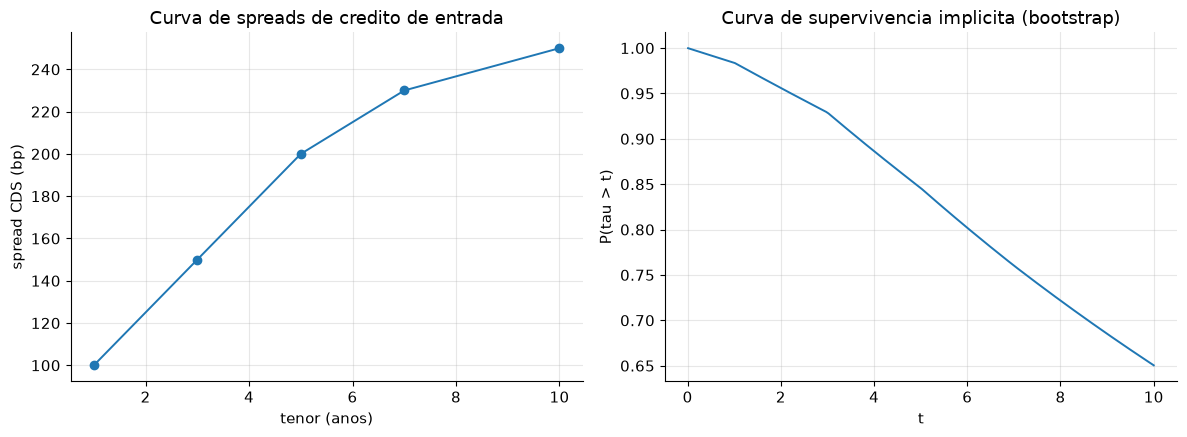

In [4]:
t_grid = np.linspace(0.01, 10, 200)
surv_curve = np.array([survival(hazards, boundaries, t) for t in t_grid])

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(tenors, spreads_mkt * 1e4, "o-")
axes[0].set_xlabel("tenor (anos)"); axes[0].set_ylabel("spread CDS (bp)")
axes[0].set_title("Curva de spreads de credito de entrada")

axes[1].plot(t_grid, surv_curve)
axes[1].set_xlabel("t"); axes[1].set_ylabel("P(tau > t)")
axes[1].set_title("Curva de supervivencia implicita (bootstrap)")
fig.tight_layout(); plt.show()

### Demo 3 — sensibilidad CS01: signo consistente ante un shock paralelo de spreads

El **CS01** (credit spread 01) mide cuánto cambia el valor de una posición de CDS ya existente cuando el mercado se mueve — aquí, un shock paralelo de +1bp en todos los spreads de cotización. Rebootstrapeamos la curva de hazard con los spreads shockeados y revaluamos la posición del comprador de protección 5Y que ya tiene fijo el spread ANTIGUO (más barato): si el mercado ahora exige más spread por el mismo riesgo, la protección que ya compró vale más.

In [5]:
shock = 1e-4  # +1bp
spreads_shocked = spreads_mkt + shock
hazards_shocked, boundaries_shocked = bootstrap_hazard_curve(spreads_shocked, tenors, tau_premium, R, nelson_siegel_df)

# valor de una posicion existente de comprador de proteccion 5Y, ya bloqueada al spread ANTIGUO,
# marcada con la curva de hazard NUEVA (post-shock)
idx_5y = 2
prem_new, prot_new = cds_legs(hazards_shocked, boundaries_shocked, idx_5y, tenors, tau_premium, R, nelson_siegel_df)
value_existing_position = prot_new - spreads_mkt[idx_5y] * prem_new

print(f"valor de la posicion existente (comprador de proteccion, spread viejo) tras +1bp de shock: "
      f"{value_existing_position:.6f}")
print("(los spreads suben -> la proteccion vale mas -> quien la compro al spread viejo (mas barato) gana)")

valor de la posicion existente (comprador de proteccion, spread viejo) tras +1bp de shock: 0.000406
(los spreads suben -> la proteccion vale mas -> quien la compro al spread viejo (mas barato) gana)


## 2. Validación

Tres chequeos sobre lo ya calculado arriba: (1) el reprecio exacto de la Demo 1; (2) que el CDS vale cero exactamente en su propio spread par (la condición que define el bootstrap, verificada como identidad de precio, no solo de spread); (3) el signo del CS01 de la Demo 3.

In [6]:
check1 = max_reprice_diff < 1e-8
print(f"1. reprecio exacto de spreads de entrada: max diff={max_reprice_diff:.2e} (<1e-8? {check1})")

npv_at_par = spreads_mkt[idx_5y] * cds_legs(hazards, boundaries, idx_5y, tenors, tau_premium, R, nelson_siegel_df)[0] \
             - cds_legs(hazards, boundaries, idx_5y, tenors, tau_premium, R, nelson_siegel_df)[1]
check2 = abs(npv_at_par) < 1e-10
print(f"2. NPV=0 del CDS a su propio spread par: {npv_at_par:.2e} (<1e-10? {check2})")

check3 = value_existing_position > 0.0
print(f"3. CS01 con signo consistente (spreads suben -> proteccion existente gana valor): {check3}")

assert check1
assert check2
assert check3
print("\nValidacion completa: 3/3 dentro de tolerancia.")

1. reprecio exacto de spreads de entrada: max diff=1.39e-13 (<1e-8? True)
2. NPV=0 del CDS a su propio spread par: -1.39e-17 (<1e-10? True)
3. CS01 con signo consistente (spreads suben -> proteccion existente gana valor): True

Validacion completa: 3/3 dentro de tolerancia.


### Validación contra QuantLib (`SpreadCdsHelper` + `PiecewiseFlatHazardRate`)

Bootstrap independiente de la misma curva de crédito: se entregan a QuantLib **las mismas
cotizaciones** (spreads por tenor, mismo recovery, pagos anuales) y la misma curva de
descuento (replicada como `ql.DiscountCurve` sobre una malla fina de `nelson_siegel_df`),
y se comparan las probabilidades de supervivencia en los nodos.

Dos diferencias de convención, deliberadas y acotadas: (i) `settlesAccrual=False`, porque
la premium leg propia ignora el accrued-on-default (Sección 1); (ii) QuantLib trabaja con
fechas calendario reales y su protection leg integra por punto medio de cada periodo de
cupón, mientras la propia usa años nominales y una malla trimestral. El residuo combinado
crece con el tenor (más periodos acumulados) hasta ~2.6e-3 relativo en 10Y — de ahí la
tolerancia `rtol=5e-3`: no es una identidad algebraica entre implementaciones idénticas,
es la coincidencia de dos bootstraps con convenciones de fecha distintas sobre los mismos
datos.

In [7]:
import QuantLib as ql

eval_date = ql.Date(29, 7, 2026)
ql.Settings.instance().evaluationDate = eval_date
dc = ql.Actual365Fixed()
cal = ql.NullCalendar()

# curva de descuento QL identica a nelson_siegel_df sobre una malla fina
grid_t = np.linspace(0.0, 12.0, 145)
dates_ql = [eval_date + ql.Period(int(round(t * 365)), ql.Days) for t in grid_t]
dfs_ql = [1.0] + [float(nelson_siegel_df(dc.yearFraction(eval_date, d))) for d in dates_ql[1:]]
disc_ql = ql.YieldTermStructureHandle(ql.DiscountCurve(dates_ql, dfs_ql, dc))

helpers = [
    ql.SpreadCdsHelper(
        ql.QuoteHandle(ql.SimpleQuote(float(s))),
        ql.Period(int(ten * 12), ql.Months),
        0,                       # settlement days
        cal,
        ql.Annual,               # pagos anuales, como la premium leg propia
        ql.Unadjusted,
        ql.DateGeneration.Forward,
        dc,
        R,
        disc_ql,
        False,                   # settlesAccrual: la premium leg propia no paga accrued-on-default
        True,                    # paysAtDefaultTime
    )
    for s, ten in zip(spreads_mkt, tenors)
]
hazard_ql = ql.PiecewiseFlatHazardRate(eval_date, helpers, dc)
hazard_ql.enableExtrapolation()

max_rel_diff_ql = 0.0
print(f"{'tenor':>6} | {'S(t) propio':>12} | {'S(t) QuantLib':>13} | {'rel diff':>9}")
print("-" * 50)
for t in tenors:
    s_own = survival(list(hazards), boundaries, float(t))
    d = eval_date + ql.Period(int(round(t * 365)), ql.Days)
    s_ql = hazard_ql.survivalProbability(d)
    rel = abs(s_own / s_ql - 1.0)
    max_rel_diff_ql = max(max_rel_diff_ql, rel)
    print(f"{t:>6.1f} | {s_own:>12.6f} | {s_ql:>13.6f} | {rel:>9.2e}")

check_ql = max_rel_diff_ql < 5e-3
print(f"\n4. supervivencia propia vs bootstrap QuantLib, rtol=5e-3: {check_ql} "
      f"(max rel diff={max_rel_diff_ql:.2e})")
assert check_ql
print("\nValidacion QuantLib completa: 1/1 dentro de tolerancia.")

 tenor |  S(t) propio | S(t) QuantLib |  rel diff
--------------------------------------------------
   1.0 |     0.983851 |      0.983978 |  1.29e-04
   3.0 |     0.928917 |      0.929366 |  4.83e-04
   5.0 |     0.845829 |      0.846727 |  1.06e-03
   7.0 |     0.760308 |      0.761622 |  1.72e-03
  10.0 |     0.650422 |      0.652125 |  2.61e-03

4. supervivencia propia vs bootstrap QuantLib, rtol=5e-3: True (max rel diff=2.61e-03)

Validacion QuantLib completa: 1/1 dentro de tolerancia.


## Referencias

- O'Kane, D., Turnbull, S. (2003). *Valuation of Credit Default Swaps*. Lehman Brothers
  Quantitative Credit Research.
- Brigo, D., Mercurio, F. (2006). *Interest Rate Models — Theory and Practice*, cap.
  21-22 (crédito).